<a href="https://colab.research.google.com/github/m1deey/Churn_customer_prediction/blob/main/02_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [129]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                               recall_score, precision_score, fbeta_score,
                               accuracy_score, precision_recall_curve)
import matplotlib.pyplot as plt

In [130]:
df = pd.read_csv("cleaned_churn_data.csv")
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Yes,No,-1.277445,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,-1.160323,-0.994242,No
1,0,No,No,0.066327,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,-0.259629,-0.173244,No
2,0,No,No,-1.236724,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,-0.362660,-0.959674,Yes
3,0,No,No,0.514251,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),-0.746535,-0.194766,No
4,0,No,No,-1.236724,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,0.197365,-0.940470,Yes


#Encoding

In [132]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
               'StreamingMovies', 'PaperlessBilling', 'MultipleLines']

service_replace_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                         'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

for col in service_replace_cols:
    df[col] = df[col].replace(['No internet service', 'No phone service'], 'No')

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

We split the data

In [133]:
y = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop("Churn", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']]))
])

onehot_pipeline = Pipeline([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('ord', ordinal_pipeline, ['Contract']),
    ('nom', onehot_pipeline, ['PaymentMethod', 'InternetService'])
], remainder='passthrough')

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

Trying multiple models

In [134]:
Lr = LogisticRegression(max_iter=1000)
Lr.fit(X_train_t, y_train)
y_pred_lr = Lr.predict(X_test_t)

print("=== Logistic Regression (default threshold) ===")
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

=== Logistic Regression (default threshold) ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

[[924 111]
 [168 206]]


The recall is low because of imbalanced output we have to fix thresholds

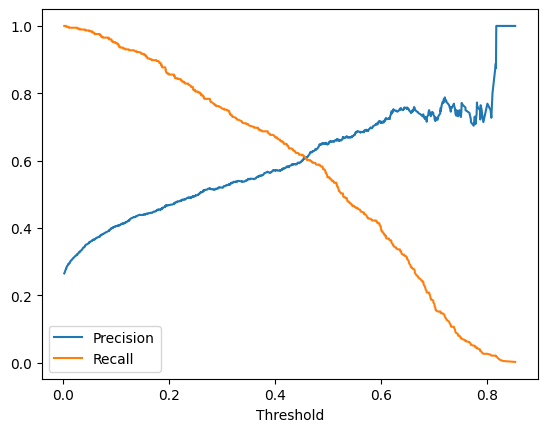

In [136]:
from sklearn.metrics import precision_recall_curve

y_proba = Lr.predict_proba(X_test_t)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

import matplotlib.pyplot as plt
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.show()

In [137]:
best_threshold_lr = 0.35
y_pred_tuned = (y_proba >= best_threshold_lr).astype(int)

print("=== Logistic Regression (tuned threshold 0.35) ===")
print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

=== Logistic Regression (tuned threshold 0.35) ===
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1035
           1       0.54      0.70      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.77      1409

[[815 220]
 [111 263]]


In [138]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_dt.fit(X_train_t, y_train)

print("best parameters:", grid_dt.best_params_)
print("best Recall (CV):", grid_dt.best_score_)

best_dt = grid_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test_t)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_best_dt))
print(confusion_matrix(y_test, y_pred_best_dt))

best parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
best Recall (CV): 0.7993311036789298
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409

[[763 272]
 [ 77 297]]


In [139]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'class_weight': [None, 'balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train_t, y_train)

print("__ Random Forest Best Params __")
print(grid_rf.best_params_)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_t)

print("__ Random Forest __")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

__ Random Forest Best Params __
{'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
__ Random Forest __
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

[[757 278]
 [ 72 302]]


#Check
The most important feature

In [140]:
importances = best_rf.feature_importances_
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

print(importance_df)

                                Feature  Importance
0                         ord__Contract    0.274704
9                     remainder__tenure    0.166559
4      nom__InternetService_Fiber optic    0.129058
2   nom__PaymentMethod_Electronic check    0.086339
20              remainder__TotalCharges    0.078905
19            remainder__MonthlyCharges    0.072059
5               nom__InternetService_No    0.058835
12            remainder__OnlineSecurity    0.034038
18          remainder__PaperlessBilling    0.021513
15               remainder__TechSupport    0.019152


Contract is the most important fueture that the company have to consider

#Finale comparison table

In [141]:
results_data = []
models_results = {
    'Logistic Regression (tuned)': y_pred_tuned,
    'Decision Tree (tuned)': y_pred_tuned_dt,
    'Random Forest': y_pred_rf
}

for name, preds in models_results.items():
    results_data.append({
        'Model': name,
        'Accuracy': f"{accuracy_score(y_test, preds):.2%}",
        'Recall': f"{recall_score(y_test, preds):.2%}",
        'Precision': f"{precision_score(y_test, preds):.2%}",
        'F2 Score': f"{fbeta_score(y_test, preds, beta=2):.2%}"
    })

df_results = pd.DataFrame(results_data)
print(df_results.to_markdown(index=False))

| Model                       | Accuracy   | Recall   | Precision   | F2 Score   |
|:----------------------------|:-----------|:---------|:------------|:-----------|
| Logistic Regression (tuned) | 76.51%     | 70.32%   | 54.45%      | 66.45%     |
| Decision Tree (tuned)       | 77.22%     | 74.06%   | 55.29%      | 69.35%     |
| Random Forest               | 75.16%     | 80.75%   | 52.07%      | 72.74%     |


RandomForest is slightly better then the other model it have higher recall and balnced precisions and accuracy

#Testing
Now we test it on a new data (dangerous constumer) to see what it give us

In [150]:
def predict_churn(customer_data):

    input_df = pd.DataFrame([customer_data])


    binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'OnlineSecurity',
                   'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                   'StreamingMovies', 'PaperlessBilling', 'MultipleLines']

    for col in binary_cols:
        input_df[col] = input_df[col].map({'Yes': 1, 'No': 0,'Male':1,'Female':0})


    input_df = input_df[X.columns]


    input_transformed = preprocessor.transform(input_df)

    prediction = best_rf.predict(input_transformed)[0]
    probability = best_rf.predict_proba(input_transformed)[0][1]
    result = "(Churn) " if prediction == 1 else " (No Churn) "

    print(f"predict: {result}")
    print(f"probability Churn: {probability:.2%}")

    return prediction, probability

In [151]:
customer_1 = {
    'gender':'Male',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 2,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 95.0,
    'TotalCharges': 190.0
}

predict_churn(customer_1)

predict: (Churn) 
probability Churn: 56.01%


(np.int64(1), np.float64(0.5600804149413068))

It correctly predicted that consumer will be churn